# Linear Regression Model
### Linear Regression for Inference: Does Production Budget Significantly Influence Revenue?
- Dataset: tn.movie_budgets.csv.gz
- Model: OLS regression (statsmodels)
- Outcome variable: worldwide_gross
- Predictor: production_budget
- Goal: Infer the strength and significance of the relationship 

### Import Necessary Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from scipy import stats
import statsmodels.api as sm

### Load and Prepare Modeling Data

In [2]:
file_path = 'C:/Users/maggi/Downloads/movie_budgets'
name = 'tn.movie_budgets.csv'
full_path = f'{file_path}/{name}'
df4 = pd.read_csv(full_path)
df4.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


In [3]:
# Prepare data
# Select only the two needed columns
model_df = df4[['production_budget', 'worldwide_gross']].copy()

# Remove '$' and ',' characters before converting
model_df['production_budget'] = model_df['production_budget'].replace(r'[\$,]', '', regex=True)
model_df['worldwide_gross'] = model_df['worldwide_gross'].replace(r'[\$,]', '', regex=True)

# Convert production_budget and worldwide_gross to numeric safely
model_df['production_budget'] = pd.to_numeric(model_df['production_budget'], errors='coerce')
model_df['worldwide_gross'] = pd.to_numeric(model_df['worldwide_gross'], errors='coerce')

# Drop any rows with NaNs
model_df = model_df.dropna()

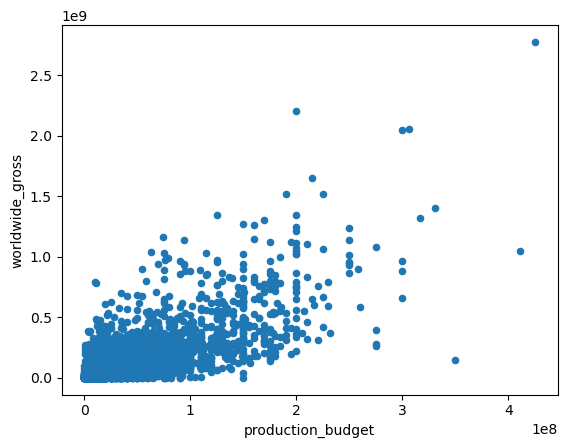

In [4]:
# Visualise the data
model_df.plot.scatter(x="production_budget", y="worldwide_gross");

## Create Linear Regression Model

In [5]:
# Determine the X and y Variables
X = sm.add_constant(model_df[['production_budget']])
y = model_df['worldwide_gross']

# Create the model
model = sm.OLS(y, X)

# Fit model
results = model.fit()

# Summary output
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:        worldwide_gross   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     7355.
Date:                Thu, 01 May 2025   Prob (F-statistic):               0.00
Time:                        15:59:37   Log-Likelihood:            -1.1557e+05
No. Observations:                5782   AIC:                         2.311e+05
Df Residuals:                    5780   BIC:                         2.311e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -7.286e+06   1.91e+0

### Interprete the model results
- The coefficient for production_budget is approximately 2.73.
- For every additional $1 spent on production, worldwide gross revenue increases by approximately $2.73.
- The p-value for the production_budget coefficient is < 0.001, indicating strong statistical significance.
- R-squared value is around 0.57, meaning production budget explains 57% of the variation in gross revenue.
- The 95% confidence interval for the coefficient does not include zero, confirming a significant positive relationship.

### Visualizing the Model

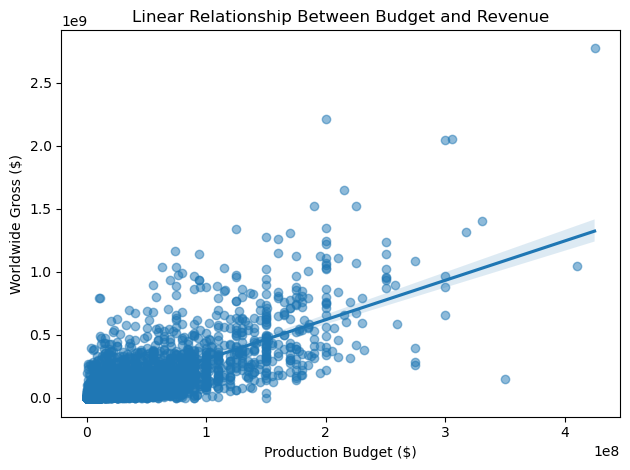

In [9]:
# Visualization: Regression Plot
sns.regplot(x='production_budget', y='worldwide_gross', data=model_df, scatter_kws={'alpha':0.5})
plt.title('Linear Relationship Between Budget and Revenue')
plt.xlabel('Production Budget ($)')
plt.ylabel('Worldwide Gross ($)')
plt.tight_layout()
plt.savefig('regression_plot.png')
plt.show()

Observation: The regression plot shows a positive linear relationship between production budget and worldwide gross revenue.
The scatter suggests variability increases with budget, meaning high-budget films have less predictable returns.

### Plotting the Residuals

In [ ]:
results.resid

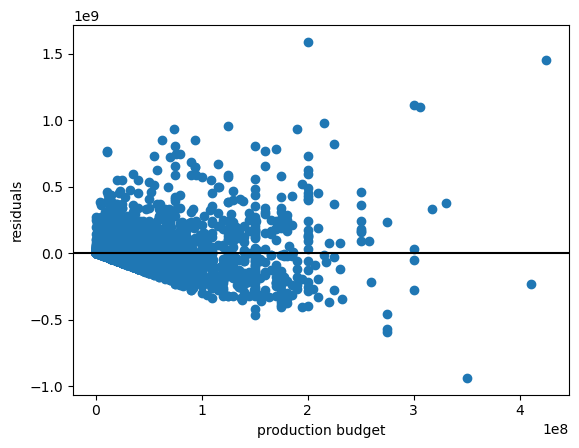

In [7]:
fig, ax = plt.subplots()

ax.scatter(model_df["production_budget"], results.resid)
ax.axhline(y=0, color="black")
ax.set_xlabel("production budget")
ax.set_ylabel("residuals");

Observation:
Residuals are roughly centered around zero, which supports the linearity assumption.
Some spread increases at higher fitted values, indicating possible heteroscedasticity (variance of the residuals is not constant).
This suggests the model performs better at lower budget levels and less consistently at higher levels.

# Regression Model Conclusion
There is a statistically significant and positive relationship between a film’s production budget and its worldwide gross revenue. 
Higher production budgets generally lead to higher expected revenues.
However, since budget explains only about 57% of revenue variability, other factors like genre, marketing, and release timing also play critical roles.
Strategic investment in production budgets, combined with strong genre and release strategies, will maximize profitability.